### Intro

1. **Обработка данных:**    
   - Удалил выбросы, которые были только в train, а test не было. 
   - Преобразовал категориальные признаки с помощью `CatBoostEncoder`, оставив только числовые признаки.  
   - Удалил признаки, показавшие сильные отличия между train и test при adversarial validation. Например, как `name`.

2. **Выбор алгоритма:**  
   Я протестировал несколько моделей: `RandomForest`, `GradientBoosting`, `XGBoost`.  
   Финальное решение реализовано с использованием **XGBoost**, так как он показал наилучшую метрику на кросс-валидации и стабильную работу на тестовых данных.

3. **Особенности обучения:**  
   Для XGBoost были настроены гиперпараметры: глубина деревьев, learning rate и количество итераций. Обучение проводилось на очищенных и сбалансированных признаках. Отбор признаков частично производился на основе важности по результатам adversarial validation.

4. **Валидация:**  
   Использовал кросс-валидацию с помощью `StratifiedKFold`. Это позволило объективно оценить обобщающую способность модели и избежать переобучения.

---

### Outro

Возможные пути улучшения метрики:

1. **Идея №1: Подбор гиперпараметров через Optuna или GridSearch**  
   Что сделать: автоматизировать поиск параметров модели XGBoost с помощью Optuna, чтобы улучшить баланс между переобучением и недообучением.

2. **Идея №2: Отбор признаков через SHAP или permutation importance**  
   Что сделать: убрать признаки с минимальной важностью и переобучить модель на оставшихся, чтобы уменьшить шум и повысить точность.

3. **Идея №3: Использование стекинга вместо простого выбора лучшей модели**
   Реализация: обучить мета-модель (например, LinearRegression или XGBoost) на предсказаниях базовых моделей. Это может лучше учесть вклад каждой модели.


Ник: vital228, позиция 21.


![Место в сореновании]('https://yadi.sk/i/zlNDF9sj8XG9Tg')

Ссылка на скриншот: https://yadi.sk/i/zlNDF9sj8XG9Tg

In [95]:
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

In [96]:
from sklearn import set_config
set_config(transform_output="pandas")

In [97]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample_data = pd.read_csv("sample_submition.csv")

In [98]:
# Подсчет уникальных значений для всех столбцов
print(train.nunique())

name                36076
_id                 29141
host_name            9629
location_cluster        5
location              220
lat                 16968
lon                 13295
type_house              3
sum                   625
min_days               96
amt_reviews           370
last_dt              1694
avg_reviews           890
total_host             47
target                366
dtype: int64


In [99]:
train['ts_last_dt'] = pd.to_datetime(train['last_dt'])
test['ts_last_dt'] = pd.to_datetime(test['last_dt'])

# Заполняем нейтральным значением, где amt_reviews == 0
neutral_avg = train['avg_reviews'].median()  # или mean()
train.loc[(train['avg_reviews'].isna()) & (train['amt_reviews'] == 0), 'avg_reviews'] = neutral_avg
neutral_avg = test['avg_reviews'].median()  # или mean()
test.loc[(test['avg_reviews'].isna()) & (test['amt_reviews'] == 0), 'avg_reviews'] = neutral_avg

min_date =  min(test['ts_last_dt'].min(), train['ts_last_dt'].min())
train.loc[(train['ts_last_dt'].isna()) & (train['amt_reviews'] == 0), 'ts_last_dt'] = min_date
test.loc[(test['ts_last_dt'].isna()) & (test['amt_reviews'] == 0), 'ts_last_dt'] = min_date

max_date = max(train['ts_last_dt'].max(), test['ts_last_dt'].max())

train['days_since_last_review'] = (max_date - train['ts_last_dt']).dt.days
test['days_since_last_review'] = (max_date - test['ts_last_dt']).dt.days


cat_features = [
    'location_cluster',  # кластеризация местоположений - категориальный признак
    'type_house',  # тип жилья - категориальный признак
    'host_name',
    'location'
]

numeric_features = [
    '_id',
    'lat',  # широта - числовой признак
    'lon',  # долгота - числовой признак
    'sum',  # общая стоимость - числовой признак
    'min_days',  # минимальное количество дней - числовой признак
    'amt_reviews',  # количество отзывов - числовой признак
    'avg_reviews',  # средний рейтинг - числовой признак
    'total_host',  # общее количество объектов у хоста - числовой признак
    'days_since_last_review'
]

_id train 0 test 0
lat train 77 test 21
lon train 916 test 320
sum train 284 test 104
min_days train 242 test 110
amt_reviews train 915 test 292
avg_reviews train 704 test 188
total_host train 493 test 187
days_since_last_review train 0 test 0


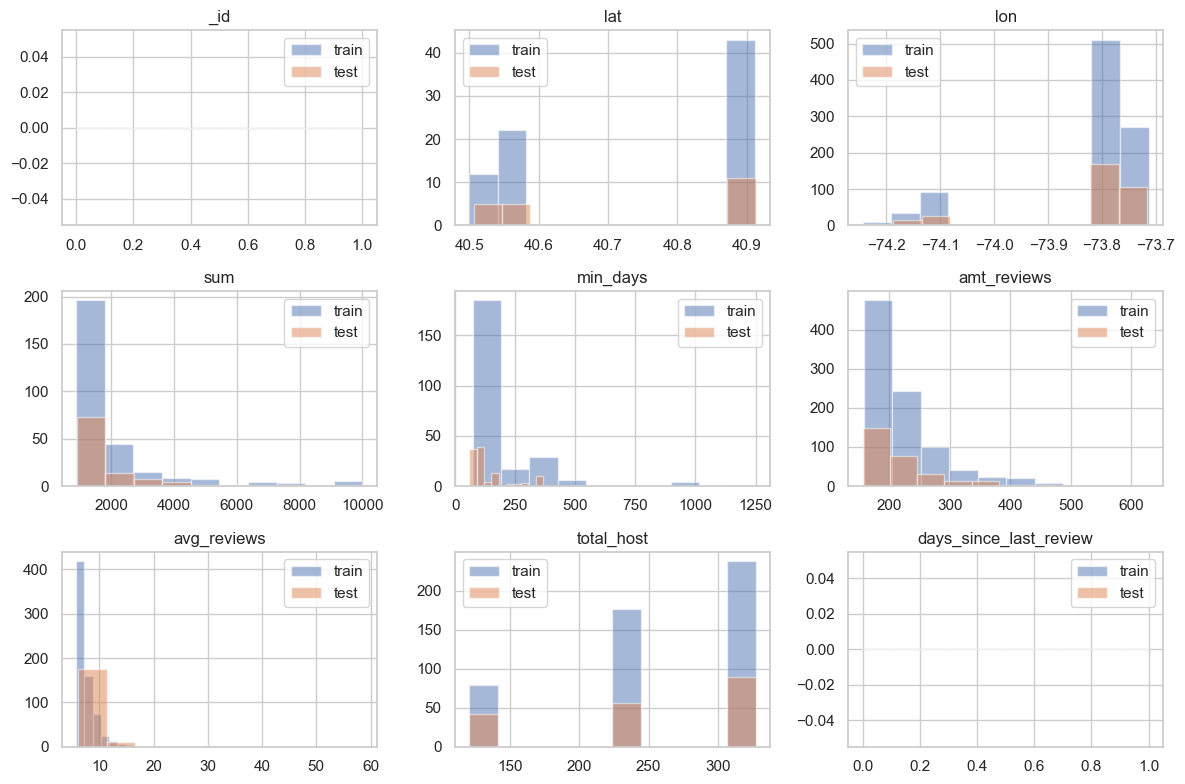

In [100]:
plt.figure(figsize=(12, 8))
for i, one_feature in enumerate(numeric_features):
  plt.subplot(3, 3, i+1)
  mask_outliesr_train = np.abs(zscore(train[one_feature].values)) >= 3
  mask_outliesr_test = np.abs(zscore(test[one_feature].values)) >= 3

  print(
      one_feature,
      'train', sum(mask_outliesr_train),
      'test', sum(mask_outliesr_test),
  )

  plt.hist(train[mask_outliesr_train][one_feature], alpha=0.5, label='train')
  plt.hist(test[mask_outliesr_test][one_feature], alpha=0.5, label='test')
  plt.legend()
  plt.title(one_feature)
plt.tight_layout()
plt.show()

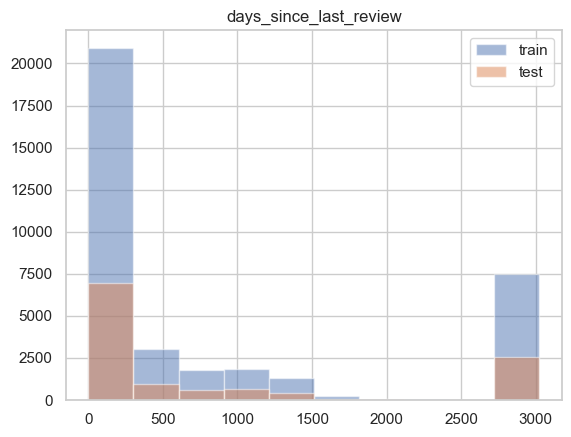

In [101]:
plt.hist(train[one_feature], alpha=0.5, label='train')
plt.hist(test[one_feature], alpha=0.5, label='test')
plt.legend()
plt.title(one_feature)
plt.show()

In [102]:
train = train[train['min_days']<400]

## Feature engeniring

In [103]:
import category_encoders as ce

target_enc = ce.CatBoostEncoder(cols=cat_features)
target_enc = target_enc.fit(train[cat_features], train['target'])

train = train.join(target_enc.transform(train[cat_features]).add_suffix('_cb'))
test = test.join(target_enc.transform(test[cat_features]).add_suffix('_cb'))

In [104]:
import numpy as np
from math import atan2, cos, radians, sin, sqrt


def haversine_distance(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта расстояния от точки А до Б по прямой

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Дистанция по прямой с точностью до n_digits
    """

    lat1, lon1, lat2, lon2 = round(lat1, 6), round(lon1, 6), round(lat2, 6), round(lon2, 6)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)

    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2

    return round(2 * 6372800 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)), n_digits)  # метры.сантиметры


def bearing_degree(lat1: float, lon1: float, lat2: float, lon2: float, n_digits: int = 0) -> float:
    """
        Функция для расчёта угла между прямой [((lat1, lon1), (lat2, lon2)), (нулевой мередиан)]

        :param lat1: Широта точки А
        :param lon1: Долгота точки А
        :param lat2: Широта точки Б
        :param lon2: Долгота точки Б
        :param n_digits: Округляем полученный ответ до n знака после запятой
        :return: Значение угла с точностью до n_digits
    """

    lat1, lon1 = np.radians(round(lat1, 6)), np.radians(round(lon1, 6))
    lat2, lon2 = np.radians(round(lat2, 6)), np.radians(round(lon2, 6))

    dlon = (lon2 - lon1)
    numerator = np.sin(dlon) * np.cos(lat2)
    denominator = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    theta = np.arctan2(numerator, denominator)
    theta_deg = (np.degrees(theta) + 360) % 360

    return round(theta_deg, n_digits)

In [105]:
train['bearing_degree_1'] = bearing_degree(train['lat'], train['lon'], 0, 0, ).values
test['bearing_degree_1'] = bearing_degree(test['lat'], test['lon'], 0, 0, ).values

train['hav_dist_1'] = haversine_distance(train['lat'], train['lon'], 0, 0, ).values
test['hav_dist_1'] = haversine_distance(test['lat'], test['lon'], 0, 0, ).values

In [106]:
train.columns

Index(['name', '_id', 'host_name', 'location_cluster', 'location', 'lat',
       'lon', 'type_house', 'sum', 'min_days', 'amt_reviews', 'last_dt',
       'avg_reviews', 'total_host', 'target', 'ts_last_dt',
       'days_since_last_review', 'location_cluster_cb', 'type_house_cb',
       'host_name_cb', 'location_cb', 'bearing_degree_1', 'hav_dist_1'],
      dtype='object')

In [107]:
def adversarial_validation(X_train, X_test, n_folds=5, random_state=42):
    """
    Функция для проведения adversarial validation между тренировочным и тестовым набором данных.

    Параметры:
    X_train - тренировочный набор данных (pandas DataFrame или Series)
    X_test - тестовый набор данных (pandas DataFrame или Series)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов

    Возвращает:
    mean_auc - среднее значение ROC AUC
    feature_importance - важность признаков
    """

    # Проверяем типы входных данных и преобразуем Series в DataFrame при необходимости
    if isinstance(X_train, pd.Series):
        X_train = X_train.to_frame()

    if isinstance(X_test, pd.Series):
        X_test = X_test.to_frame()

    # Проверяем, что входные данные являются pandas DataFrame
    if not isinstance(X_train, pd.DataFrame) or not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_train и X_test должны быть pandas DataFrame или Series")

    # Проверяем, что все колонки имеют имена
    if any(not isinstance(col, str) for col in X_train.columns) or any(not isinstance(col, str) for col in X_test.columns):
        raise ValueError("Все колонки в X_train и X_test должны иметь строковые имена")

    # Проверяем, что наборы данных имеют одинаковые колонки
    if set(X_train.columns) != set(X_test.columns):
        raise ValueError("Колонки в тренировочном и тестовом наборах должны совпадать")

    # Создаем новый целевой признак: 0 для тренировочных данных, 1 для тестовых
    X_train_labeled = X_train.copy()
    X_test_labeled = X_test.copy()

    X_train_labeled['is_test'] = 0
    X_test_labeled['is_test'] = 1

    # Объединяем данные в один датасет
    combined_data = pd.concat([X_train_labeled, X_test_labeled], axis=0)

    # Перемешиваем данные
    combined_data = combined_data.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Выделяем признаки и целевую переменную
    X = combined_data.drop('is_test', axis=1)
    y = combined_data['is_test']

    # Проверяем, что все колонки в X содержат числовые данные
    non_numeric_cols = [col for col in X.columns if not np.issubdtype(X[col].dtype, np.number)]
    if non_numeric_cols:
        raise ValueError(f"Следующие колонки содержат нечисловые данные: {non_numeric_cols}. "
                         f"Преобразуйте их в числовой формат перед использованием.")

    # Инициализируем модель XGBoost
    model = XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        n_estimators=100,
        objective='binary:logistic',
        random_state=random_state
    )

    # Инициализируем кросс-валидацию
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Списки для хранения результатов
    auc_scores = []
    y_true_all = []
    y_pred_all = []

    # Проводим кросс-валидацию
    for i, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Получаем предсказания вероятностей
        y_pred = model.predict_proba(X_fold_val)[:, 1]

        # Вычисляем ROC AUC
        auc = roc_auc_score(y_fold_val, y_pred)
        auc_scores.append(auc)

        # Сохраняем результаты для построения общей ROC-кривой
        y_true_all.extend(y_fold_val)
        y_pred_all.extend(y_pred)

        print(f"Фолд {i+1}: ROC AUC = {auc:.4f}")

    # Вычисляем среднее значение ROC AUC
    mean_auc = np.mean(auc_scores)
    print(f"\nСреднее значение ROC AUC: {mean_auc:.4f}")

    # Обучаем модель на всех данных для получения важности признаков
    final_model = XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        n_estimators=100,
        objective='binary:logistic',
        random_state=random_state
    )
    final_model.fit(X, y)

    # Получаем важность признаков
    feature_importance = pd.DataFrame({
        'Признак': X.columns,
        'Важность': final_model.feature_importances_
    }).sort_values('Важность', ascending=False)

    # Строим ROC-кривую
    fpr, tpr, _ = roc_curve(y_true_all, y_pred_all)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {mean_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая для Adversarial Validation')
    plt.legend()
    plt.grid(True)

    # Выводим топ-10 важных признаков
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(min(10, len(feature_importance)))
    plt.barh(top_features['Признак'], top_features['Важность'])
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.title('Топ-10 признаков по важности')
    plt.gca().invert_yaxis()  # Инвертируем ось Y для отображения самых важных признаков сверху

    return mean_auc, feature_importance

In [108]:
model_features = [
  '_id',
  'lat',  # широта - числовой признак
  'lon',  # долгота - числовой признак
  'sum',  
  'min_days',
  'amt_reviews', 
  'avg_reviews', 
  'total_host',
  'days_since_last_review',
  'location_cluster_cb', 
  'type_house_cb',
  'host_name_cb',
  'location_cb',
  'bearing_degree_1', 
  'hav_dist_1'
]

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    train[model_features],
    train['target'],
    test_size=0.25,
    random_state=42,
    stratify=train['target'],
)

In [110]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oe, cat_features)
    ], remainder='passthrough'
)

In [111]:
# X_train = preprocessor.fit_transform(X_train)
# X_test = preprocessor.transform(X_test)

Фолд 1: ROC AUC = 0.4965
Фолд 2: ROC AUC = 0.5103
Фолд 3: ROC AUC = 0.5196
Фолд 4: ROC AUC = 0.5140
Фолд 5: ROC AUC = 0.4939

Среднее значение ROC AUC: 0.5069


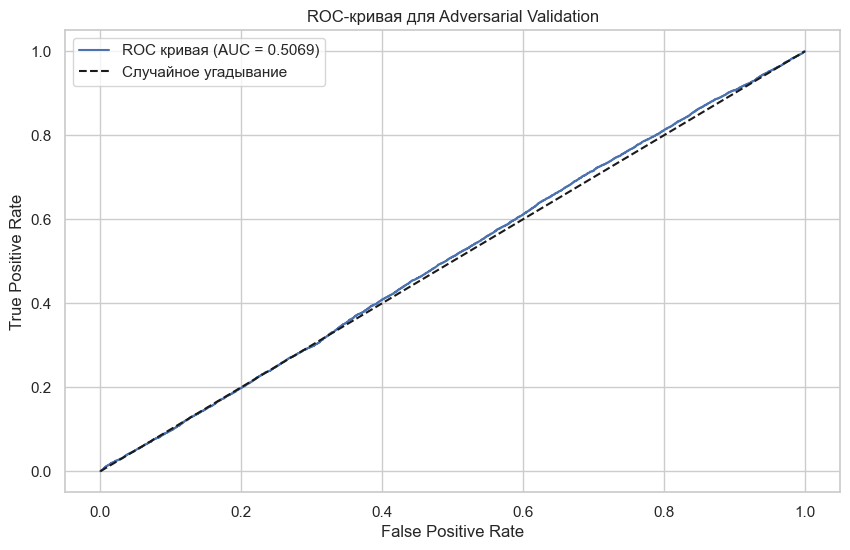

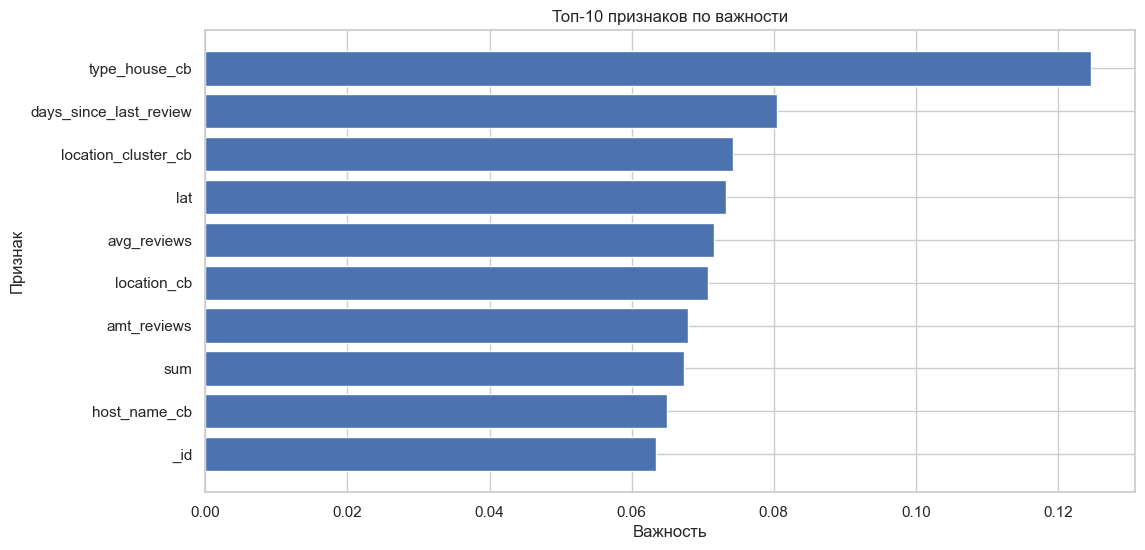

In [112]:
mean_auc, feature_importance = adversarial_validation(X_train, X_test)

In [113]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
import xgboost as xgb

In [114]:
def visualize_residuals(y_true, y_pred, dataset_name=""):
    """
    Функция для визуализации остатков регрессионной модели

    Параметры:
    y_true - истинные значения целевой переменной
    y_pred - предсказанные значения
    dataset_name - название набора данных для заголовков графиков
    """
    # Вычисляем остатки
    residuals = y_true - y_pred

    # Создаем фигуру с подграфиками
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Анализ остатков ({dataset_name})', fontsize=16)

    # 1. График остатков относительно предсказанных значений
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='-')
    axes[0, 0].set_title('Остатки vs Предсказанные значения')
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True)

    # 2. Гистограмма остатков
    axes[0, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Гистограмма остатков')
    axes[0, 1].set_xlabel('Остатки')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True)

    # 3. QQ-график для проверки нормальности остатков
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-график остатков')
    axes[1, 0].grid(True)

    # 4. Предсказанные vs Истинные значения
    axes[1, 1].scatter(y_true, y_pred, alpha=0.5)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    axes[1, 1].set_title('Предсказанные vs Истинные значения')
    axes[1, 1].set_xlabel('Истинные значения')
    axes[1, 1].set_ylabel('Предсказанные значения')
    axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Оставляем место для общего заголовка
    plt.show()

In [115]:
def cross_validation_with_residuals(
    X_train, y_train, X_test, y_test, X_oot=None, y_oot=None,
    model=None, n_folds=5, random_state=42
    ):
    """
    Функция для проведения кросс-валидации с отслеживанием MSE и визуализацией остатков

    Параметры:
    X_train - признаки обучающей выборки (pandas DataFrame)
    y_train - целевая переменная обучающей выборки (pandas Series или numpy array)
    X_test - признаки тестовой выборки (pandas DataFrame)
    y_test - целевая переменная тестовой выборки (pandas Series или numpy array)
    X_oot - признаки out-of-time выборки (pandas DataFrame), опционально
    y_oot - целевая переменная out-of-time выборки (pandas Series или numpy array), опционально
    model - модель машинного обучения (по умолчанию RandomForestRegressor)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов

    Возвращает:
    cv_results - словарь с результатами кросс-валидации
    final_model - обученная модель на всех тренировочных данных
    """

    # Проверка входных данных
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train должен быть pandas DataFrame")

    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test должен быть pandas DataFrame")

    if X_oot is not None and not isinstance(X_oot, pd.DataFrame):
        raise TypeError("X_oot должен быть pandas DataFrame")

    # Проверка, что все наборы данных имеют одинаковые колонки
    if not set(X_train.columns) == set(X_test.columns):
        raise ValueError("Колонки в X_train и X_test должны совпадать")

    if X_oot is not None and not set(X_train.columns) == set(X_oot.columns):
        raise ValueError("Колонки в X_train и X_oot должны совпадать")

    # Если модель не задана, используем RandomForestRegressor по умолчанию
    if model is None:
        model = RandomForestRegressor(n_estimators=100, random_state=random_state)

    # Инициализируем KFold для кросс-валидации
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Словарь для хранения результатов
    cv_results = {
        'train_predictions': np.zeros(len(y_train)),
        'train_actual': y_train,
        'test_predictions': None,
        'test_actual': y_test,
        'oot_predictions': None,
        'oot_actual': y_oot if y_oot is not None else None,
        'fold_mse': [],
        'train_mse': 0,
        'test_mse': 0,
        'oot_mse': 0 if y_oot is not None else None
    }

    # Массивы для хранения предсказаний и истинных значений по фолдам
    fold_train_mse = []
    fold_val_mse = []

    print("Начинаем процесс кросс-валидации...")

    # Проходим по всем фолдам
    for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train), total=n_folds, desc="Фолды")):
        # Разделяем данные на обучающую и валидационную выборки
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx] if isinstance(y_train, pd.Series) else y_train[train_idx], \
                                  y_train.iloc[val_idx] if isinstance(y_train, pd.Series) else y_train[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Делаем предсказания на обучающей и валидационной выборках
        y_fold_train_pred = model.predict(X_fold_train)
        y_fold_val_pred = model.predict(X_fold_val)

        # Сохраняем предсказания для этого фолда
        cv_results['train_predictions'][val_idx] = y_fold_val_pred

        # Вычисляем MSE для этого фолда
        train_mse = mean_squared_error(y_fold_train, y_fold_train_pred)
        val_mse = mean_squared_error(y_fold_val, y_fold_val_pred)

        fold_train_mse.append(train_mse)
        fold_val_mse.append(val_mse)
        cv_results['fold_mse'].append(val_mse)

        print(f"Фолд {fold+1}/{n_folds}:")
        print(f"  MSE на обучающей выборке: {train_mse:.4f}")
        print(f"  MSE на валидационной выборке: {val_mse:.4f}")

    # Вычисляем средние значения MSE
    cv_results['train_mse'] = np.mean(fold_train_mse)
    cv_results['val_mse'] = np.mean(fold_val_mse)

    print(f"\nСредняя MSE на обучающей выборке: {cv_results['train_mse']:.4f}")
    print(f"Средняя MSE на валидационной выборке: {cv_results['val_mse']:.4f}")

    # Обучаем финальную модель на всех тренировочных данных
    print("\nОбучаем финальную модель на всех тренировочных данных...")
    final_model = model.fit(X_train, y_train)

    # Делаем предсказания на тестовой выборке
    cv_results['test_predictions'] = final_model.predict(X_test)

    # Вычисляем MSE на тестовой выборке
    cv_results['test_mse'] = mean_squared_error(y_test, cv_results['test_predictions'])
    print(f"MSE на тестовой выборке: {cv_results['test_mse']:.4f}")

    # Если есть OOT данные, делаем предсказания на них
    if X_oot is not None and y_oot is not None:
        cv_results['oot_predictions'] = final_model.predict(X_oot)
        cv_results['oot_mse'] = mean_squared_error(y_oot, cv_results['oot_predictions'])
        print(f"MSE на OOT выборке: {cv_results['oot_mse']:.4f}")

    # Визуализация результатов
    visualize_cv_results(cv_results, n_folds)

    # Визуализация остатков
    visualize_residuals(y_test, cv_results['test_predictions'], "Тестовая выборка")

    # Если есть OOT данные, визуализируем остатки для них
    if X_oot is not None and y_oot is not None:
        visualize_residuals(y_oot, cv_results['oot_predictions'], "OOT выборка")

    return cv_results, final_model

def visualize_cv_results(cv_results, n_folds):
    """
    Функция для визуализации результатов кросс-валидации

    Параметры:
    cv_results - словарь с результатами кросс-валидации
    n_folds - количество фолдов
    """
    # Настраиваем стиль графиков
    sns.set(style="whitegrid")

    # 1. График MSE по фолдам
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_folds+1), cv_results['fold_mse'], color='skyblue')
    plt.axhline(y=np.mean(cv_results['fold_mse']), color='r', linestyle='-',
               label=f'Среднее: {np.mean(cv_results["fold_mse"]):.4f}')
    plt.title('MSE по фолдам')
    plt.xlabel('Номер фолда')
    plt.ylabel('MSE')
    plt.xticks(range(1, n_folds+1))
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Сравнение предсказаний и реальных значений на тренировочных данных
    plt.figure(figsize=(10, 6))
    plt.scatter(cv_results['train_actual'], cv_results['train_predictions'], alpha=0.5)
    min_val = min(min(cv_results['train_actual']), min(cv_results['train_predictions']))
    max_val = max(max(cv_results['train_actual']), max(cv_results['train_predictions']))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title('Предсказания vs Реальные значения (Тренировочные данные)')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказания')
    plt.grid(True)
    plt.show()

    # 3. Сравнение предсказаний и реальных значений на тестовых данных
    plt.figure(figsize=(10, 6))
    plt.scatter(cv_results['test_actual'], cv_results['test_predictions'], alpha=0.5)
    min_val = min(min(cv_results['test_actual']), min(cv_results['test_predictions']))
    max_val = max(max(cv_results['test_actual']), max(cv_results['test_predictions']))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title('Предсказания vs Реальные значения (Тестовые данные)')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказания')
    plt.grid(True)
    plt.show()

    # 4. Если есть OOT данные, визуализируем их
    if cv_results['oot_predictions'] is not None:
        plt.figure(figsize=(10, 6))
        plt.scatter(cv_results['oot_actual'], cv_results['oot_predictions'], alpha=0.5)
        min_val = min(min(cv_results['oot_actual']), min(cv_results['oot_predictions']))
        max_val = max(max(cv_results['oot_actual']), max(cv_results['oot_predictions']))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        plt.title('Предсказания vs Реальные значения (OOT данные)')
        plt.xlabel('Реальные значения')
        plt.ylabel('Предсказания')
        plt.grid(True)
        plt.show()

    # 5. Сравнение MSE на разных наборах данных
    plt.figure(figsize=(10, 6))

    # Собираем метрики для всех наборов данных
    datasets = ['Кросс-валидация', 'Тест']
    mse_values = [cv_results['val_mse'], cv_results['test_mse']]

    if cv_results['oot_mse'] is not None:
        datasets.append('OOT')
        mse_values.append(cv_results['oot_mse'])

    plt.bar(datasets, mse_values, color='skyblue')
    plt.title('Сравнение MSE на разных наборах данных')
    plt.ylabel('MSE')
    plt.grid(True)

    # Добавляем значения MSE над столбцами
    for i, v in enumerate(mse_values):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

    plt.show()

In [116]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import warnings

def cross_validation_with_residuals_hyper(
    X_train, y_train, X_test, y_test, X_oot=None, y_oot=None,
    models_to_try='all', param_grids='default', n_folds=5, 
    random_state=42, search_method='random', n_iter=50,
    verbose=1
):
    """
    Улучшенная функция для проведения кросс-валидации с подбором гиперпараметров и модели
    
    Параметры:
    X_train - признаки обучающей выборки (pandas DataFrame)
    y_train - целевая переменная обучающей выборки (pandas Series или numpy array)
    X_test - признаки тестовой выборки (pandas DataFrame)
    y_test - целевая переменная тестовой выборки (pandas Series или numpy array)
    X_oot - признаки out-of-time выборки (pandas DataFrame), опционально
    y_oot - целевая переменная out-of-time выборки (pandas Series или numpy array), опционально
    models_to_try - какие модели тестировать ('all', 'default' или список моделей)
    param_grids - словарь с параметрами для поиска ('default' или пользовательский)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов
    search_method - метод поиска гиперпараметров ('grid' или 'random')
    n_iter - количество итераций для RandomizedSearchCV
    verbose - уровень детализации (0, 1 или 2)
    
    Возвращает:
    cv_results - словарь с результатами кросс-валидации
    final_model - лучшая обученная модель на всех тренировочных данных
    best_model_name - название лучшей модели
    """
    
    # Проверка входных данных
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train должен быть pandas DataFrame")
    
    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test должен быть pandas DataFrame")
    
    if X_oot is not None and not isinstance(X_oot, pd.DataFrame):
        raise TypeError("X_oot должен быть pandas DataFrame")
    
    # Проверка совпадения колонок
    if not set(X_train.columns) == set(X_test.columns):
        raise ValueError("Колонки в X_train и X_test должны совпадать")
    
    if X_oot is not None and not set(X_train.columns) == set(X_oot.columns):
        raise ValueError("Колонки в X_train и X_oot должны совпадать")
    
    # Определение моделей для тестирования
    if models_to_try == 'all':
        models = {
            'RandomForest': RandomForestRegressor(random_state=random_state),
            'GradientBoosting': GradientBoostingRegressor(random_state=random_state),
            'XGBoost': XGBRegressor(random_state=random_state, verbosity=0),
            'LightGBM': LGBMRegressor(random_state=random_state),
            'Ridge': Ridge(random_state=random_state),
            'Lasso': Lasso(random_state=random_state)
        }
    elif models_to_try == 'default':
        models = {
            'RandomForest': RandomForestRegressor(random_state=random_state),
            'GradientBoosting': GradientBoostingRegressor(random_state=random_state),
            'XGBoost': XGBRegressor(random_state=random_state, verbosity=0),
        }
    elif isinstance(models_to_try, dict):
        models = models_to_try
    else:
        raise ValueError("models_to_try должен быть 'all', 'default' или словарь моделей")
    
    # Определение параметров для поиска
    if param_grids == 'default':
        param_grids = {
            'RandomForest': {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'GradientBoosting': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5],
                'min_samples_split': [2, 5]
            },
            'XGBoost': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5, 6],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0]
            },
            'LightGBM': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'num_leaves': [31, 50, 100],
                'max_depth': [-1, 5, 10]
            },
            'Ridge': {
                'alpha': [0.1, 1.0, 10.0, 100.0]
            },
            'Lasso': {
                'alpha': [0.1, 1.0, 10.0, 100.0]
            },
            'SVR': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        }
    elif not isinstance(param_grids, dict):
        raise ValueError("param_grids должен быть 'default' или словарь параметров")
    
    # Убедимся, что для всех моделей есть параметры
    for model_name in models:
        if model_name not in param_grids:
            warnings.warn(f"Нет параметров для модели {model_name}, будут использованы параметры по умолчанию")
            param_grids[model_name] = {}
    
    # Результаты по всем моделям
    all_models_results = {}
    
    
    # Перебираем все модели
    for model_name, model in models.items():
        if verbose >= 1:
            print(f"\n{'='*50}")
            print(f"Начинаем подбор параметров для модели: {model_name}")
            print(f"{'='*50}")
        
        # Выбираем метод поиска
        if search_method == 'grid':
            search = GridSearchCV(
                estimator=model,
                param_grid=param_grids[model_name],
                cv=n_folds,
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=verbose
            )
        elif search_method == 'random':
            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grids[model_name],
                n_iter=n_iter,
                cv=n_folds,
                scoring='neg_mean_squared_error',
                random_state=random_state,
                n_jobs=-1,
                verbose=verbose
            )
        else:
            raise ValueError("search_method должен быть 'grid' или 'random'")
        
        # Выполняем поиск
        search.fit(X_train, y_train)
        
        # Сохраняем результаты
        all_models_results[model_name] = {
            'best_model': search.best_estimator_,
            'best_params': search.best_params_,
            'best_score': -search.best_score_,  # преобразуем обратно в MSE
            'cv_results': search.cv_results_
        }
        
        if verbose >= 1:
            print(f"\nЛучшие параметры для {model_name}: {search.best_params_}")
            print(f"Лучший MSE (CV): {all_models_results[model_name]['best_score']:.4f}")
    
    # Выбираем лучшую модель
    best_model_name = min(all_models_results, key=lambda x: all_models_results[x]['best_score'])
    best_model = all_models_results[best_model_name]['best_model']
    best_score = all_models_results[best_model_name]['best_score']
    
    if verbose >= 1:
        print(f"\n{'='*50}")
        print(f"Лучшая модель: {best_model_name} с MSE {best_score:.4f}")
        print(f"{'='*50}")
    
    # Обучаем лучшую модель на всех данных
    final_model = best_model.fit(X_train, y_train)
    
    # Подготовка результатов
    cv_results = {
        'all_models_results': all_models_results,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'best_score': best_score,
        'train_predictions': final_model.predict(X_train),
        'train_actual': y_train,
        'test_predictions': final_model.predict(X_test),
        'test_actual': y_test,
        'train_mse': mean_squared_error(y_train, final_model.predict(X_train)),
        'test_mse': mean_squared_error(y_test, final_model.predict(X_test))
    }
    
    # Если есть OOT данные
    if X_oot is not None and y_oot is not None:
        cv_results.update({
            'oot_predictions': final_model.predict(X_oot),
            'oot_actual': y_oot,
            'oot_mse': mean_squared_error(y_oot, final_model.predict(X_oot))
        })
    
    if verbose >= 1:
        print(f"\nРезультаты на полном обучении:")
        print(f"MSE на обучающей выборке: {cv_results['train_mse']:.4f}")
        print(f"MSE на тестовой выборке: {cv_results['test_mse']:.4f}")
        if X_oot is not None and y_oot is not None:
            print(f"MSE на OOT выборке: {cv_results['oot_mse']:.4f}")
    
    # Визуализация результатов
    # visualize_cv_results(cv_results, n_folds)
    visualize_residuals(y_test, cv_results['test_predictions'], "Тестовая выборка")
    if X_oot is not None and y_oot is not None:
        visualize_residuals(y_oot, cv_results['oot_predictions'], "OOT выборка")
    
    return cv_results, final_model, best_model_name

Начинаем процесс кросс-валидации...


Фолды:  20%|██        | 1/5 [00:17<01:08, 17.01s/it]

Фолд 1/5:
  MSE на обучающей выборке: 1240.9627
  MSE на валидационной выборке: 8710.7760


Фолды:  40%|████      | 2/5 [00:33<00:50, 16.94s/it]

Фолд 2/5:
  MSE на обучающей выборке: 1232.5019
  MSE на валидационной выборке: 9155.9671


...

Фолды:  80%|████████  | 4/5 [01:07<00:16, 16.87s/it]

Фолд 4/5:
  MSE на обучающей выборке: 1243.4204
  MSE на валидационной выборке: 9110.0932


Фолды: 100%|██████████| 5/5 [01:24<00:00, 16.97s/it]

Фолд 5/5:
  MSE на обучающей выборке: 1248.3166
  MSE на валидационной выборке: 8865.9209

Средняя MSE на обучающей выборке: 1244.2105
Средняя MSE на валидационной выборке: 8943.8433

Обучаем финальную модель на всех тренировочных данных...


MSE на тестовой выборке: 8910.0927


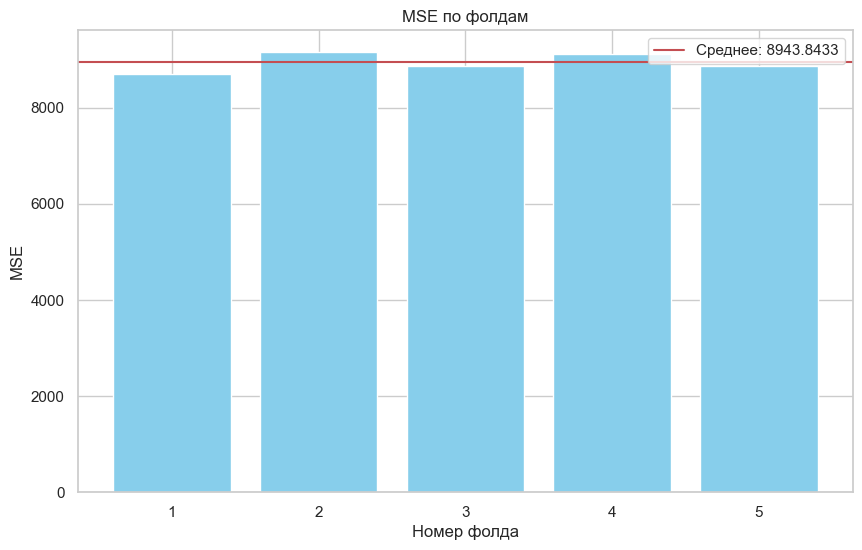

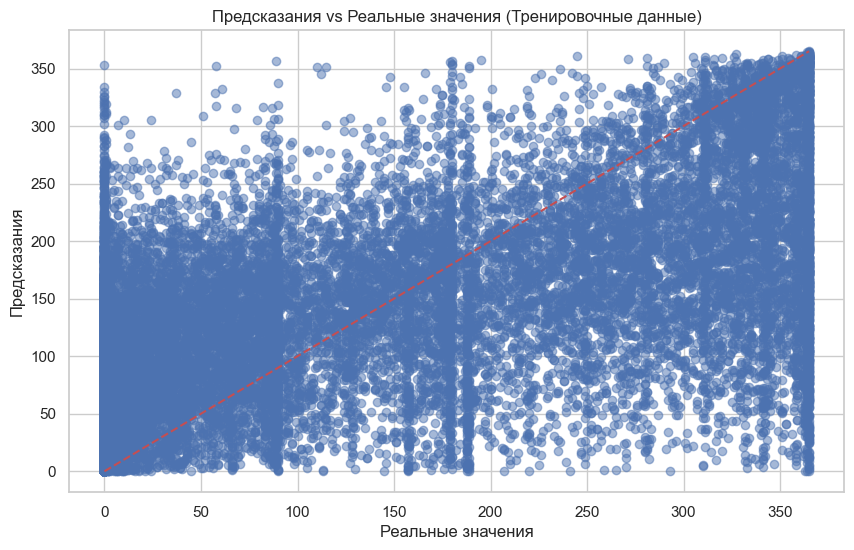

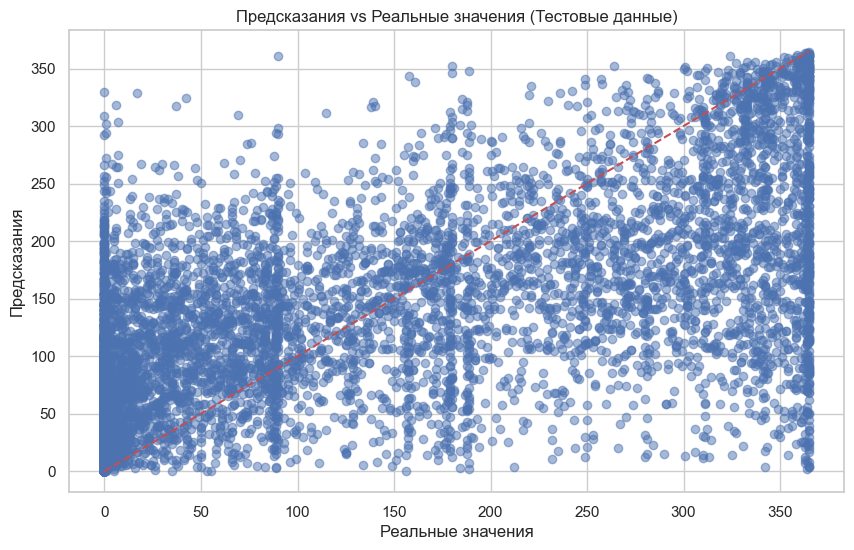

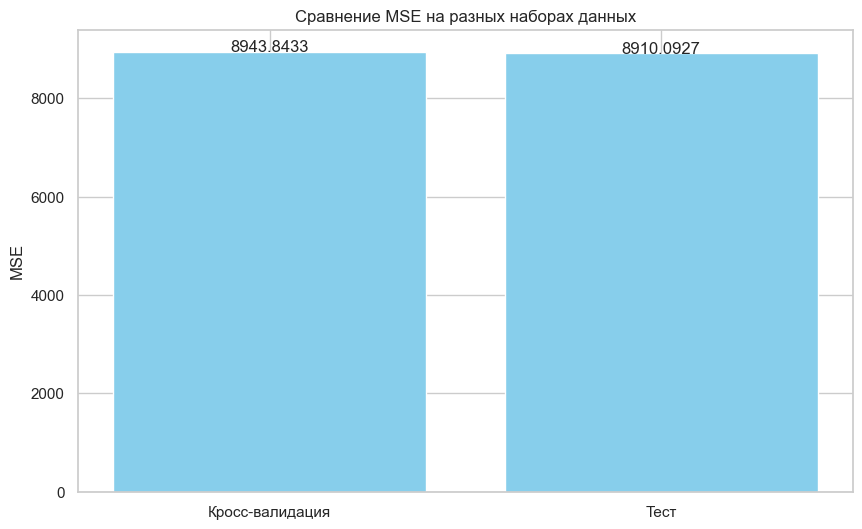

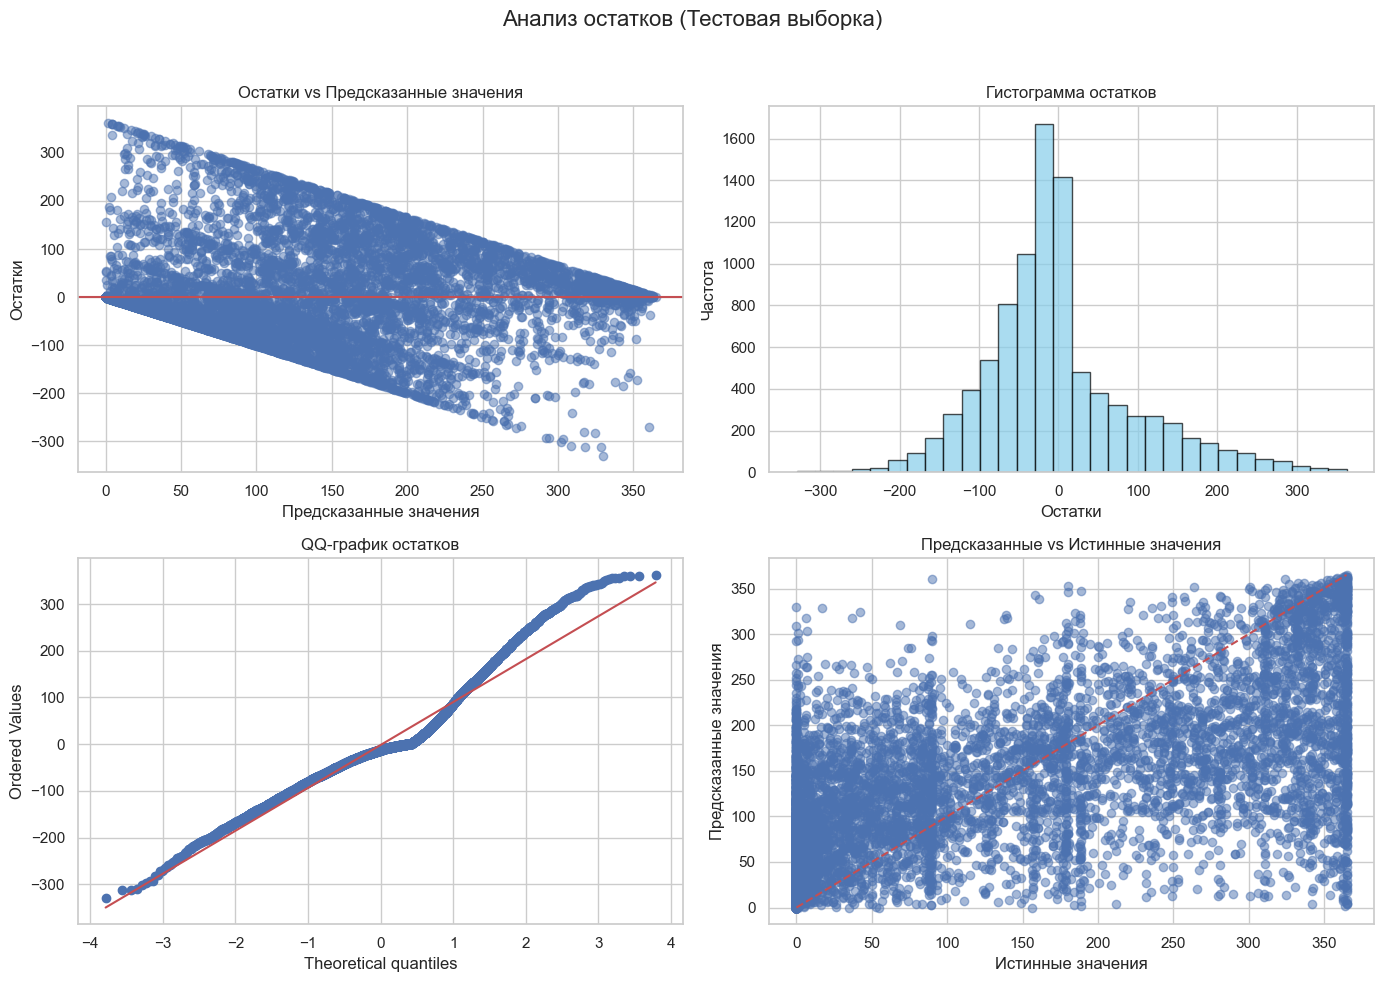

In [117]:
cv_result, model = cross_validation_with_residuals(X_train, y_train, X_test, y_test, n_folds=5, model = RandomForestRegressor(n_estimators=100, random_state=42))


Начинаем подбор параметров для модели: RandomForest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Лучшие параметры для RandomForest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
Лучший MSE (CV): 8786.3718

Начинаем подбор параметров для модели: GradientBoosting
Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\user\source\repos\SHAD_MTS_24_25\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 36 is smaller than n_iter=50. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Лучшие параметры для GradientBoosting: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}
Лучший MSE (CV): 8787.2958

Начинаем подбор параметров для модели: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Лучшие параметры для XGBoost: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Лучший MSE (CV): 8676.4824

Лучшая модель: XGBoost с MSE 8676.4824

Результаты на полном обучении:
MSE на обучающей выборке: 6802.8818
MSE на тестовой выборке: 8788.4385


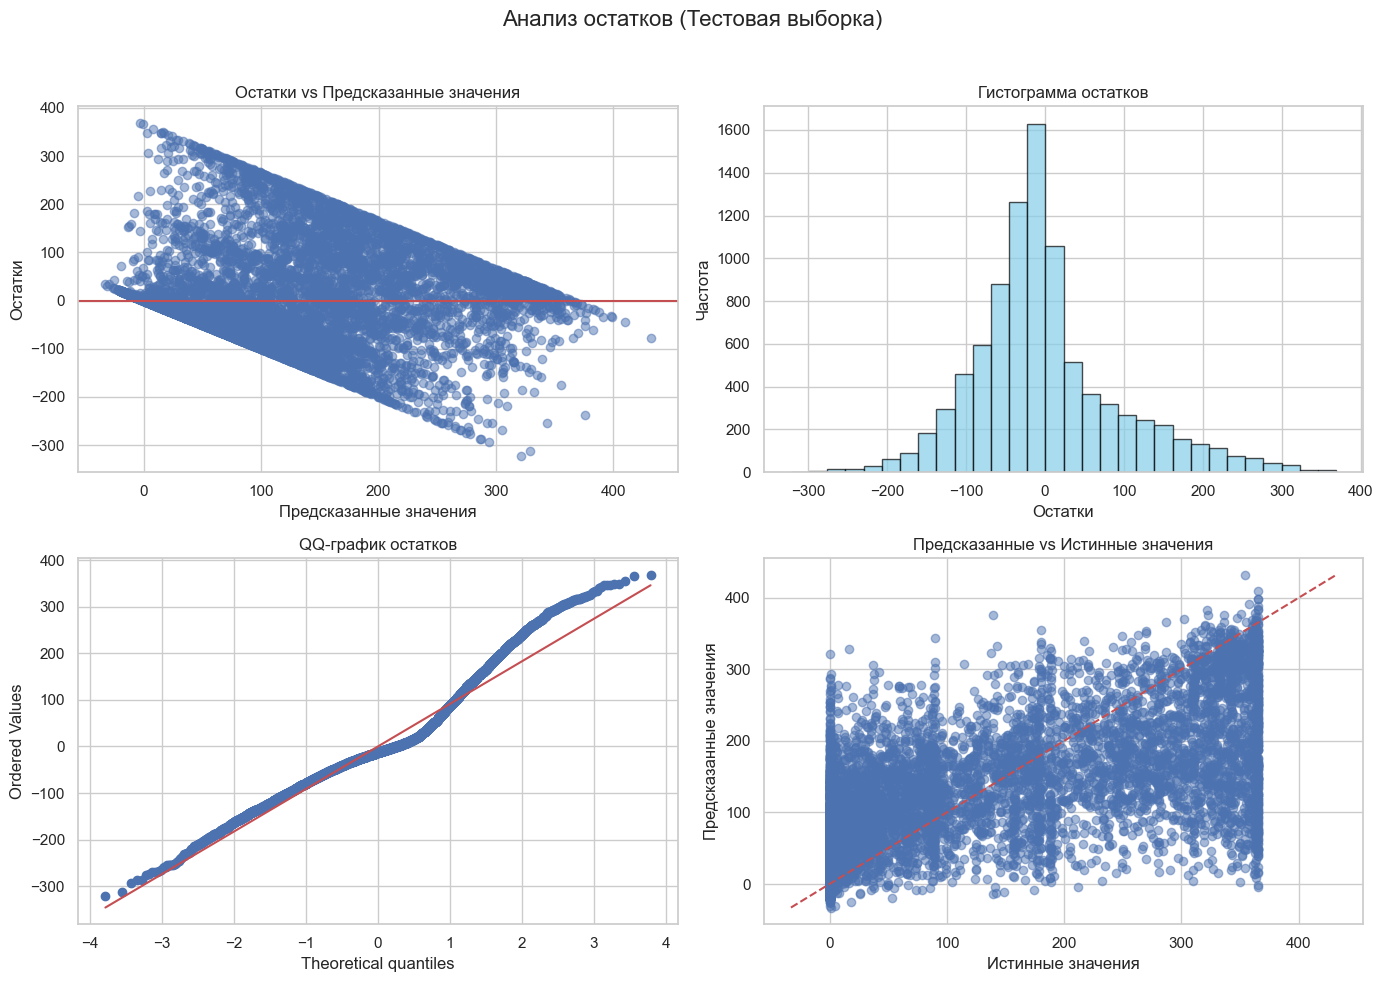

In [118]:
param_grids = {
            'RandomForest': {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 5, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'GradientBoosting': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5],
                'min_samples_split': [2, 5]
            },
            'XGBoost': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5, 6],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0]
            },
}

cv_results, final_model, best_model_name = cross_validation_with_residuals_hyper(X_train, y_train, X_test, y_test, param_grids=param_grids, models_to_try='default')

In [119]:
predict = final_model.predict(test[model_features])

In [120]:
print(predict)
sample_data['prediction'] = predict
sample_data.to_csv('sample_submition_1.csv', index=False)

[155.22867   202.99243   320.2496    ... 265.41345    -6.0465074
 225.57787  ]
